# 3. Inference and final metrics

Running the saved model the way the organisers do, robustness to bad input, final metrics with bootstrap confidence intervals (2000 resamples over groups), age subgroups, calibration and the estimated score.

All metrics come from the out-of-fold predictions of nested validation: every subject is predicted by a model that never saw them. Predictions of the final model on its own training data are optimistic and shown only for comparison.

In [1]:
import shutil
import sys
import tempfile
import time
import warnings
from pathlib import Path

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "results" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

from model.model import load, predict, run
from src import config, dataset, evaluation, models, viz

warnings.filterwarnings("ignore", message="Mean of empty slice")
viz.apply_style()
pd.set_option("display.precision", 3)
WEIGHTS = ROOT / "model" / "weights"
OOF_PATH = ROOT / "results" / "validation" / "protocol8" / "nested_oof.csv"

## 3.1 Running the model like the organisers

`load` reads the weights, `run` walks through the subject folders and writes a CSV with `subject_id, ptsd_probability`. As an example, one subject from each group is copied to a temporary folder.

In [2]:
model = load(WEIGHTS)
print(f"Model: {model.metadata['protocol']}, {model.metadata['candidate']}, {len(model.feature_names)} features; "
      f"Platt calibration a = {model.calibration[0]:.3f}, b = {model.calibration[1]:.3f}")

data = models.load_training_data(protocol=models.PROTOCOL_8)
stratum_of = dict(zip(data.subject_keys, data.stratum))
demo = [next(k for k in data.subject_keys if stratum_of[k] == s) for s in viz.STRATUM_ORDER]

tmp = Path(tempfile.mkdtemp())
input_dir = tmp / "input"
for key in demo:
    shutil.copytree(config.DATA_DIR / key, input_dir / Path(key).name)
start = time.perf_counter()
run(model, input_dir, tmp / "predictions.csv")
elapsed = time.perf_counter() - start
predictions = pd.read_csv(tmp / "predictions.csv", encoding="utf-8-sig")
print(f"{len(predictions)} subjects in {elapsed:.1f} s ({elapsed / len(predictions):.2f} s per subject)")
predictions.assign(group=[viz.STRATUM_LABELS[stratum_of[k]] for k in sorted(demo, key=lambda k: Path(k).name)])

Model: protocol8, C=1.0|neg=control+somatoform|feat=rest_O1FpT_exp, 23 features; Platt calibration a = 0.822, b = 0.236


7 subjects in 0.8 s (0.12 s per subject)


,subject_id,ptsd_probability,group
0,34PHG,0.713,PTSD
1,A003_68,0.014,controls 65+
2,ABXZ5,0.467,somatoform
3,КС010_19,0.837,control A
4,КС027_34,0.785,control B
5,КС056_22,0.134,control C
6,КС201_23,0.585,suppl. controls


These subjects were part of the training data, so this only checks that the run works.

## 3.2 Bad input

An empty folder, rest only, a truncated EDF file and Cyrillic file names.

In [3]:
bad_dir = tmp / "bad_input"
source = config.DATA_DIR / demo[0]
(bad_dir / "empty").mkdir(parents=True)
(bad_dir / "rest_only").mkdir()
shutil.copy(source / "T-П.edf", bad_dir / "rest_only" / "T-П.edf")
(bad_dir / "truncated").mkdir()
(bad_dir / "truncated" / "T-П.edf").write_bytes((source / "T-П.edf").read_bytes()[:3000])
(bad_dir / "cyrillic_names").mkdir()
shutil.copy(source / "T-П.edf", bad_dir / "cyrillic_names" / "Т-П.edf")
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    run(model, bad_dir, tmp / "bad_predictions.csv")
bad = pd.read_csv(tmp / "bad_predictions.csv", encoding="utf-8-sig")
print("All probabilities finite and in [0, 1]:", bool(bad["ptsd_probability"].between(0, 1).all()))
print("Warnings:", len(caught))
bad

All probabilities finite and in [0, 1]: True
Warnings: 0


,subject_id,ptsd_probability
0,cyrillic_names,0.713
1,empty,0.201
2,rest_only,0.713
3,truncated,0.201


"Rest only" and Cyrillic names give the same P as the full set of files, because the model uses rest only. The empty folder and the damaged file get the P for "nothing known".

## 3.3 Identical features in training and inference

Probabilities computed through `predict` and from the training table for all 229 subjects:

In [4]:
start = time.perf_counter()
p_inference = np.array([predict(model, config.DATA_DIR / key) for key in data.subject_keys])
elapsed = time.perf_counter() - start
p_training = model.predict_proba(data.tables[model.metadata["feature_set"]])
print(f"Inference for 229 subjects: {elapsed:.0f} s; largest difference from the training table: "
      f"{np.abs(p_inference - p_training).max():.1e}")

Inference for 229 subjects: 15 s; largest difference from the training table: 3.3e-16


In [5]:
oof = pd.read_csv(OOF_PATH, index_col=0).loc[list(data.subject_keys)]
stratum, groups = oof["stratum"].to_numpy(), oof["split_group"].to_numpy()
ptsd = stratum == models.STRATUM_PTSD
young = np.isin(stratum, ["control_A", "control_B", "control_C", "control_B_supplement"])


def auc_vs(p: np.ndarray, negatives: np.ndarray) -> float:
    mask = ptsd | negatives
    return roc_auc_score(ptsd[mask], p[mask])


pd.DataFrame({
    "final model on its training data (optimistic)": {
        "AUC PTSD / controls < 65": auc_vs(p_inference, young),
        "AUC PTSD / controls 65+ and somatoform": auc_vs(p_inference, np.isin(stratum, ["control_ageing", "somatoform"])),
        "sensitivity at 0.5": np.mean(p_inference[ptsd] >= 0.5)},
    "nested validation, out of fold (quality estimate)": {
        "AUC PTSD / controls < 65": auc_vs(oof["p_raw"].to_numpy(), young),
        "AUC PTSD / controls 65+ and somatoform": auc_vs(oof["p_raw"].to_numpy(), np.isin(stratum, ["control_ageing", "somatoform"])),
        "sensitivity at 0.5": np.mean(oof["p"].to_numpy()[ptsd] >= 0.5)},
})

,final model on its training data (optimistic),"nested validation, out of fold (quality estimate)"
AUC PTSD / controls < 65,0.923,0.864
AUC PTSD / controls 65+ and somatoform,0.894,0.816
sensitivity at 0.5,0.960,0.840


The gap between the columns is the optimism of evaluating on training data.

## 3.4 Final metrics

"Controls under 65" are all controls younger than 65, the PTSD/control pair of the task. The composition of the test pair is unknown, so the version without format C is shown as well. Threshold metrics use the submitted probability at 0.5.

In [6]:
report = evaluation.summarize_protocol3(oof, groups)
p, p_raw = oof["p"].to_numpy(), oof["p_raw"].to_numpy()


def ci(entry: dict) -> str:
    return f"{entry['value']:.3f} [{entry['ci_low']:.3f}; {entry['ci_high']:.3f}]"


auc_rows = {"PTSD / controls < 65": "auc_ptsd_vs_controls_excl_ageing", "PTSD / controls A, B, suppl.": "auc_ptsd_vs_controls_AB"}
auc_table = pd.DataFrame({
    col: {**{name: ci(report[col][key]) for name, key in auc_rows.items()},
          **{f"PTSD / {viz.STRATUM_LABELS[s]}": f"{v:.3f}" for s, v in report[col]["auc_ptsd_vs_stratum"].items()}}
    for col in ("p_raw", "p")
}).rename(columns={"p_raw": "uncalibrated", "p": "calibrated (submitted)"})
auc_table.rename_axis("ROC-AUC")

,uncalibrated,calibrated (submitted)
ROC-AUC,,
PTSD / controls < 65,0.864 [0.796; 0.919],0.824 [0.753; 0.886]
"PTSD / controls A, B, suppl.",0.765 [0.661; 0.862],0.697 [0.589; 0.803]
PTSD / control A,0.670,0.622
PTSD / control B,0.460,0.500
PTSD / suppl. controls,0.828,0.744
PTSD / control C,1.000,1.000
PTSD / controls 65+,0.890,0.877
PTSD / somatoform,0.792,0.731


In [7]:
sens = evaluation.rate_with_ci(p[ptsd] >= 0.5, groups[ptsd])
spec_young = evaluation.rate_with_ci(p[young] < 0.5, groups[young])
threshold = {
    "sensitivity (PTSD)": ci(sens),
    "specificity: controls < 65": ci(spec_young),
    "specificity: controls 65+": ci(report["p"]["specificity_ageing"]),
    "specificity: somatoform": ci(report["p"]["specificity_somatoform"]),
    "specificity: 65+ and somatoform together": ci(report["p"]["specificity_ageing_and_somatoform_pooled"]),
    "balanced accuracy: PTSD / controls < 65": f"{0.5 * (sens['value'] + spec_young['value']):.3f}",
    "balanced accuracy: PTSD / all non-PTSD": f"{report['p']['threshold_metrics']['balanced_accuracy_vs_all_non_ptsd']:.3f}",
    "Brier score (all subjects)": f"{report['p']['brier_all_subjects']:.3f}",
}
pd.Series(threshold, name="threshold 0.5, calibrated probability").to_frame()

,"threshold 0.5, calibrated probability"
sensitivity (PTSD),0.840 [0.692; 0.958]
specificity: controls < 65,0.720 [0.636; 0.804]
specificity: controls 65+,0.870 [0.739; 1.000]
specificity: somatoform,0.608 [0.500; 0.718]
specificity: 65+ and somatoform together,0.670 [0.573; 0.760]
balanced accuracy: PTSD / controls < 65,0.780
balanced accuracy: PTSD / all non-PTSD,0.768
Brier score (all subjects),0.185


## 3.5 ROC curves

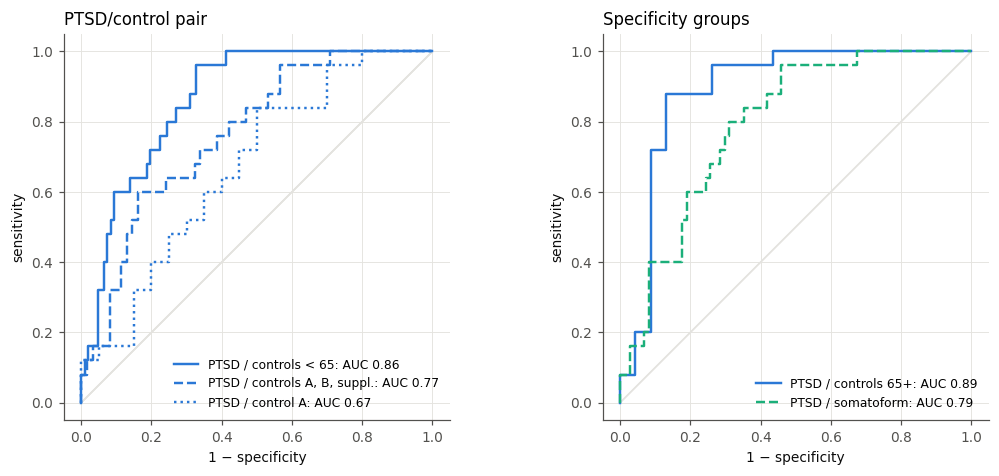

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
control = viz.COHORT_COLORS[config.GROUP_CONTROL]
panels = [
    [("controls < 65", young, "-"), ("controls A, B, suppl.", np.isin(stratum, ["control_A", "control_B", "control_B_supplement"]), "--"),
     ("control A", stratum == "control_A", ":")],
    [("controls 65+", stratum == "control_ageing", "-"), ("somatoform", stratum == "somatoform", "--")],
]
for ax, panel in zip(axes, panels):
    for label, negatives, ls in panel:
        mask = ptsd | negatives
        color = viz.COHORT_COLORS[config.GROUP_SOMATOFORM] if label == "somatoform" else control
        viz.plot_roc(ax, ptsd[mask].astype(int), p_raw[mask], f"PTSD / {label}", color, ls)
    ax.legend(loc="lower right", fontsize=8)
axes[0].set_title("PTSD/control pair", loc="left")
axes[1].set_title("Specificity groups", loc="left")
plt.tight_layout()
plt.show()

## 3.6 Probability by group

Dots are subjects, lines are medians, the dashed line is the 0.5 threshold. The table gives the share of P ≥ 0.5 with a 95% confidence interval; for PTSD this is the sensitivity.

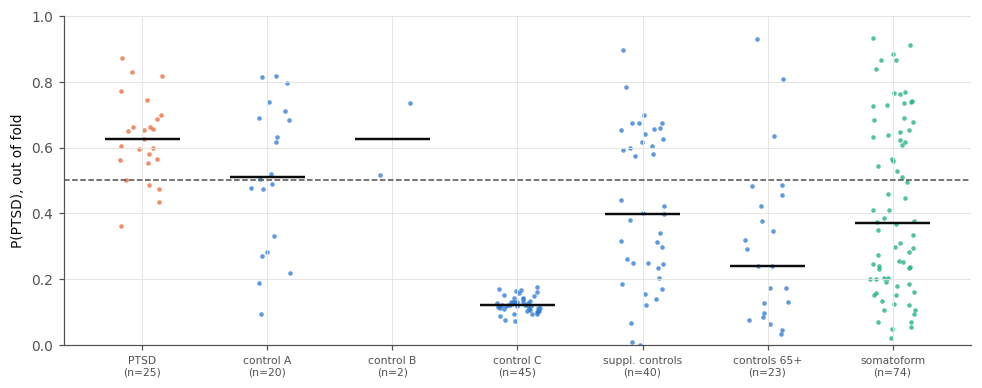

,n,share P ≥ 0.5,2.5%,97.5%,median P
PTSD,25.0,0.840,0.692,0.958,0.626
control A,20.0,0.550,0.350,0.750,0.512
control B,2.0,1.000,1.000,1.000,0.627
control C,45.0,0.000,0.000,0.000,0.121
suppl. controls,40.0,0.425,0.275,0.575,0.399
controls 65+,23.0,0.130,0.000,0.261,0.240
somatoform,74.0,0.392,0.282,0.500,0.370


In [9]:
fig, ax = plt.subplots(figsize=(9, 3.6))
viz.plot_by_stratum(ax, p, stratum)
ax.axhline(0.5, color=viz.TEXT_MUTED, ls="--", lw=1)
ax.set_ylabel("P(PTSD), out of fold")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

rows = {}
for s in viz.STRATUM_ORDER:
    m = stratum == s
    r = evaluation.rate_with_ci(p[m] >= 0.5, groups[m])
    rows[viz.STRATUM_LABELS[s]] = {"n": int(m.sum()), "share P ≥ 0.5": r["value"], "2.5%": r["ci_low"], "97.5%": r["ci_high"],
                                   "median P": float(np.median(p[m]))}
pd.DataFrame(rows).T

## 3.7 Age subgroups

Age is known for controls only. In each subgroup the AUC compares all PTSD patients with the controls of that age. Age is mixed up with batch here (composition on the right).

In [10]:
subjects = dataset.scan_dataset(config.DATA_DIR)[2]
age = subjects.loc[list(data.subject_keys), "age"].to_numpy(dtype=float)
age = np.where(np.char.startswith(stratum.astype(str), "control_"), age, np.nan)
by_age = evaluation.metrics_by_age(p, age, ptsd).join(
    evaluation.metrics_by_age(p_raw, age, ptsd)[["auc_ptsd_vs_band"]], rsuffix="_raw")
by_age = by_age.drop(columns="auc_ptsd_vs_band").rename(columns={
    "n": "controls", "median_p": "median P", "specificity": "specificity at 0.5", "auc_ptsd_vs_band_raw": "AUC PTSD / subgroup"})
bands = pd.cut(age, [0, 30, 46, 65, np.inf], right=False, labels=list(by_age.index))
composition = pd.crosstab(bands, pd.Series(stratum).map(viz.STRATUM_LABELS).to_numpy())
by_age.join(composition)

,controls,median P,specificity at 0.5,AUC PTSD / subgroup,control A,control B,control C,controls 65+,suppl. controls
17-29,65,0.269,0.631,0.828,15,0,16,0,34
30-45,28,0.153,0.821,0.903,3,2,17,0,6
46-64,14,0.115,0.929,0.954,2,0,12,0,0
65+,23,0.240,0.870,0.890,0,0,0,23,0


## 3.8 Calibration

The calibration gives both classes equal weight, so P reads as a probability under equal prior odds and the points lie below the diagonal by design. To convert to a prevalence π: `odds_π = odds · π/(1 − π)`.

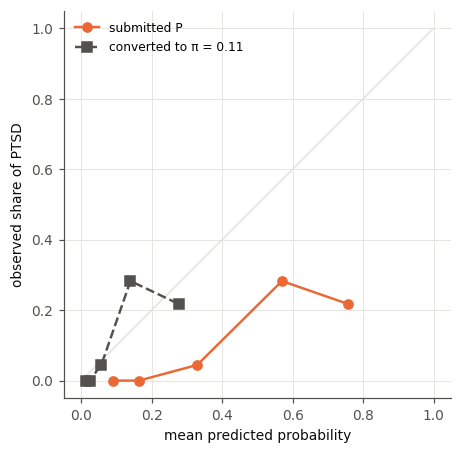

,subjects,mean P,share of PTSD,converted to the PTSD share in the data
0,46,0.090,0.000,0.012
1,46,0.164,0.000,0.023
2,45,0.329,0.044,0.057
3,46,0.570,0.283,0.140
4,46,0.757,0.217,0.277


In [11]:
rel = pd.DataFrame(report["p"]["reliability"])
prevalence = ptsd.mean()
balanced = rel["mean_p"] / (1 - rel["mean_p"]) * prevalence / (1 - prevalence)
rel["converted to the PTSD share in the data"] = balanced / (1 + balanced)
fig, ax = plt.subplots(figsize=(4.4, 4.2))
ax.plot([0, 1], [0, 1], color=viz.GRID, lw=1)
ax.plot(rel["mean_p"], rel["observed"], "o-", color=viz.COHORT_COLORS[config.GROUP_PTSD], label="submitted P")
ax.plot(rel["converted to the PTSD share in the data"], rel["observed"], "s--", color=viz.TEXT_MUTED, label=f"converted to π = {prevalence:.2f}")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed share of PTSD")
ax.set_aspect("equal")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
rel.rename(columns={"n": "subjects", "mean_p": "mean P", "observed": "share of PTSD"})

## 3.9 Estimated score by the official formula

`30·max(0, (AUC − 0.5)/0.5)` on the PTSD/control pair and `20·(1 − FPR)` on controls aged 65+ and somatoform patients at 0.5. The bounds follow the 95% confidence intervals. This is an estimate from the development data, not a forecast for the test.

In [12]:
def auc_points(a: float) -> float:
    return 30.0 * max(0.0, (a - 0.5) / 0.5)


spec_pooled = report["p"]["specificity_ageing_and_somatoform_pooled"]
score = {}
for name, key in auc_rows.items():
    a = report["p_raw"][key]
    score[f"AUC part, {name}"] = [auc_points(a["value"]), auc_points(a["ci_low"]), auc_points(a["ci_high"])]
score["specificity part, 65+ and somatoform"] = [20 * spec_pooled["value"], 20 * spec_pooled["ci_low"], 20 * spec_pooled["ci_high"]]
pd.DataFrame(score, index=["estimate", "lower bound", "upper bound"]).T.round(1)

,estimate,lower bound,upper bound
"AUC part, PTSD / controls < 65",21.8,17.8,25.1
"AUC part, PTSD / controls A, B, suppl.",15.9,9.6,21.7
"specificity part, 65+ and somatoform",13.4,11.5,15.2


## 3.10 Summary

1. The model runs through the required interface without retraining, in about a tenth of a second per subject, and does not fail on bad input. Inference features match the training features.
2. Out of sample, AUC is 0.86 against controls under 65 and lower without format C. Against control A alone the separation is weak.
3. At the 0.5 threshold the model detects most patients and rejects most older adults, while somatoform patients are the hardest group.
4. Most false positives come from control A and the supplementary batch.
5. The threshold sits at the equal-error point. Calibrating to the training prevalence would give almost perfect specificity but zero sensitivity.

In [13]:
shutil.rmtree(tmp, ignore_errors=True)